Today's topics:
* line plots
* scatter plots
* labels and legends

# Picking materials for an instrument

There is a lot of light we cannot see, and it carries real information.

<img src="https://upload.wikimedia.org/wikipedia/commons/9/97/LERF_Timisoara_RO_sunset_IR_1.jpg" alt="A thermal image of a building at sunset, warm and cool surfaces rendered as different shades rather than as colors the eye would see" width=520/>

Photo by Mihai-Cosmin Pascariu,
[CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/),
[via Wikimedia Commons](https://commons.wikimedia.org/wiki/File:LERF_Timisoara_RO_sunset_IR_1.jpg).

Above: an [infrared image](https://en.wikipedia.org/wiki/Thermographic_camera) of a
building at sunset, where the shading is temperature rather than color.

Say we're building an instrument that works just past the red end of what our eyes can
see. It needs three parts, and they want three different things from a material:

- a **lens**, which has to bend the light and lose none of it
- a **mirror**, which has to send nearly all of it back
- a **detector**, which has to soak the light up and turn it into a signal

We have four materials on the bench: silicon, gold, and two glasses, N-BK7 and fused
silica. Nothing on the label says which is which.

Each material carries two numbers at each wavelength, and they are what we'll be plotting
all day.

The **refractive index** `n` is how much the material slows light: $v = c/n$. Window glass
sits near 1.5, so light crosses it at about two thirds of its vacuum speed, and slowing at
an angle is what bends a ray through a lens.

The **extinction coefficient** `k` is how fast light fades once it is inside. It only
becomes a picture when we turn it into a depth:

| material | light | `k` | fades away after |
|---|---|---|---|
| fused silica | red | ~0 | no measurable fading |
| gold | red | 4.5 | 13 nm |
| silicon | red | 0.009 | 6.5 um |
| the same silicon | 1.45 um | ~0 | no measurable fading |

Gold stops red light within about 45 atoms' worth of metal, and almost all of it comes
back out. Silicon takes micrometers, and a wafer is thicker than that, so nothing reaches
the far side.

The last row is the same silicon as the row above it. Only the wavelength changed.

So a big `k` is a disaster in a lens and exactly what a mirror and a detector need, and
both numbers change with wavelength, which we measure in micrometers (um). That is why
this is a plotting problem and not a lookup.

We'll look at data for four materials from
[refractiveindex.info](https://refractiveindex.info), a public-domain database of measured
optical constants.

Our question for the day:
*Which of these four materials should be the lens, which the mirror, and which the
detector?*

In [1]:
#@title Load refractive index data for four materials (click ▶ to run) { display-mode: "form" }
import os

import numpy as np
import pandas as pd

_file = 'optical_constants.csv'
_github = f'https://raw.githubusercontent.com/wfreinhart/matse219/main/datasets/{_file}'
_local = next(
    (p for p in (f'datasets/{_file}', f'../datasets/{_file}', f'../../datasets/{_file}',
                 f'../../../datasets/{_file}')
     if os.path.exists(p)),
    None,
)

try:
    _table = pd.read_csv(_local if _local else _github)
except Exception as e:
    raise RuntimeError(
        f"Could not load '{_file}'. If you are in Colab, check your internet "
        f"connection and that the file exists at {_github}"
    ) from e

_si = _table[_table['material'] == 'silicon'].sort_values('wavelength_um')
_bk7 = _table[_table['material'] == 'BK7'].sort_values('wavelength_um')
_silica = _table[_table['material'] == 'fused_silica'].sort_values('wavelength_um')
_au = _table[_table['material'] == 'gold'].sort_values('wavelength_um')

wl_si, n_si, k_si = _si['wavelength_um'].to_numpy(), _si['n'].to_numpy(), _si['k'].to_numpy()
wl_bk7, n_bk7 = _bk7['wavelength_um'].to_numpy(), _bk7['n'].to_numpy()
wl_silica, n_silica = _silica['wavelength_um'].to_numpy(), _silica['n'].to_numpy()
wl_au, n_au, k_au = _au['wavelength_um'].to_numpy(), _au['n'].to_numpy(), _au['k'].to_numpy()
n_all = _table['n'].to_numpy()

print(f'Loaded {len(_table)} measurements from {_file}')
print(f'  silicon {len(wl_si)}, BK7 {len(wl_bk7)}, fused silica {len(wl_silica)}, gold {len(wl_au)}')
print(f'  wavelengths run {_table["wavelength_um"].min()} to {_table["wavelength_um"].max()} um')

Loaded 47 measurements from optical_constants.csv
  silicon 11, BK7 13, fused silica 10, gold 13
  wavelengths run 0.1879 to 5.0 um


# A line plot

Silicon, first. We have its refractive index at 11 wavelengths, in order.

In [2]:
import matplotlib.pyplot as plt

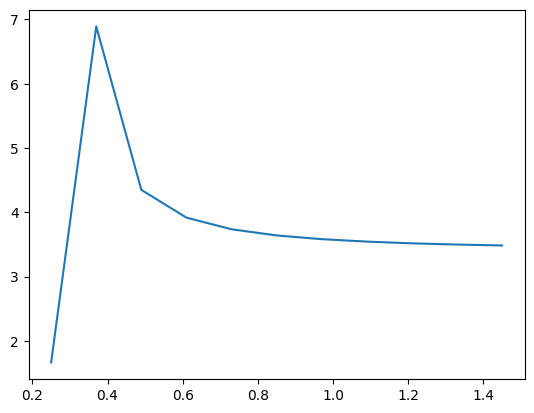

In [3]:
plt.plot(wl_si, n_si)

`plt.plot` takes the x values and the y values, pairs them off by position, and draws a
line through the points in the order they arrive.

The two arrays have to be the same length, and the pairing is the same parallel-array idea
from L03: position 4 in one is the partner of position 4 in the other.

## The axes need names

Without labels, we can no longer interpret a plot once we leave the room where we made it.

Text(0, 0.5, 'refractive index n')

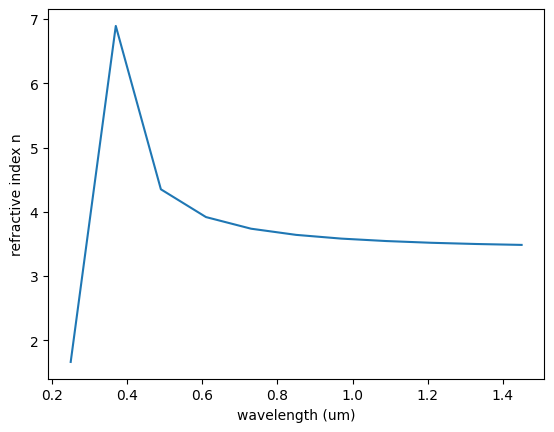

In [4]:
plt.plot(wl_si, n_si)
plt.xlabel('wavelength (um)')
plt.ylabel('refractive index n')

`plt.xlabel` and `plt.ylabel` take a string each, and they belong on every figure that
leaves the notebook.

Now the shape is readable. Silicon's index climbs steeply in the ultraviolet, peaks near
0.37 um, and settles toward 3.5 in the infrared.

## What happened to our line?

Let's do that again, with the plot in one cell and the labels in the next.

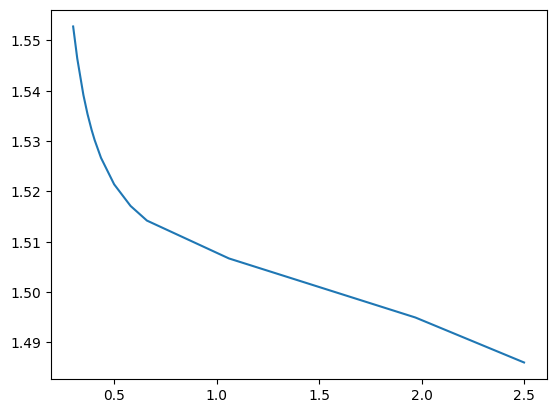

In [5]:
plt.plot(wl_bk7, n_bk7)

Text(0, 0.5, 'refractive index n')

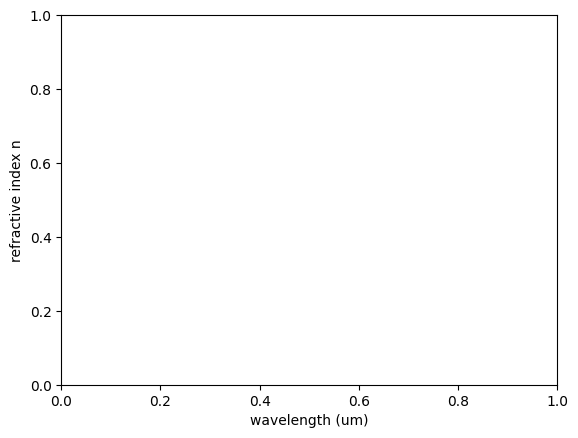

In [6]:
plt.xlabel('wavelength (um)')
plt.ylabel('refractive index n')

The labels arrived on an empty pair of axes, and the line is gone.

We have not made a single variable for the chart so far. Every call has been a `pyplot` function, and
`pyplot` holds the chart behind the scenes in what it calls a **state machine**: there is
a current figure, and each call adds to it.

Running a new cell starts a new one, so the second cell put its labels on a fresh figure
that had nothing drawn on it.

# Making persistent figures

To keep a chart between cells, we ask for it by name instead of letting `pyplot` hold it
for us. `plt.subplots()` gives us two things: the **figure**, which is the whole image,
and the **axes**, which is the box the data goes in.

Figure(640x480)
Axes(0.125,0.11;0.775x0.77)


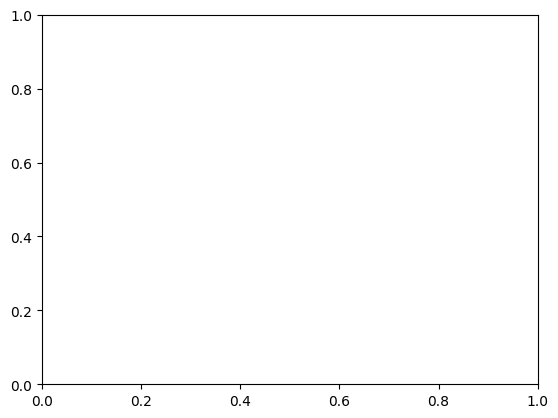

In [7]:
figure, axes = plt.subplots()
print(figure)
print(axes)

Now the chart is in variables, and we draw by calling methods on `axes` instead of
functions on `plt`:

Text(0, 0.5, 'refractive index n')

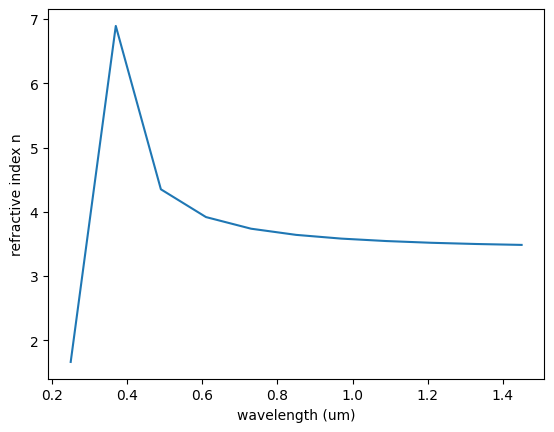

In [8]:
figure, axes = plt.subplots()
axes.plot(wl_si, n_si)
axes.set_xlabel('wavelength (um)')
axes.set_ylabel('refractive index n')

The drawing call keeps its name: `plt.plot` becomes `axes.plot`. The label calls pick up
a `set_` in front, so `plt.xlabel` becomes `axes.set_xlabel`.

The figure is a variable now, so a later cell can still reach it. Naming it on a line of
its own draws it again:

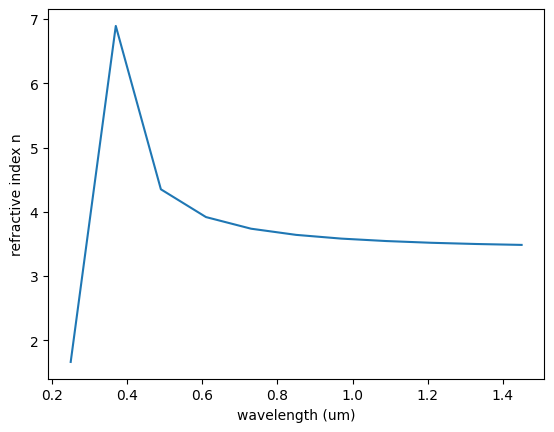

In [9]:
figure

The usual shorthand for these two names is `fig` and `ax`, which is what the rest of this
course uses.

## Several materials, one figure

Let's put three materials on one figure. Each `ax.plot` call draws onto the same `ax`.

Text(0, 0.5, 'refractive index n')

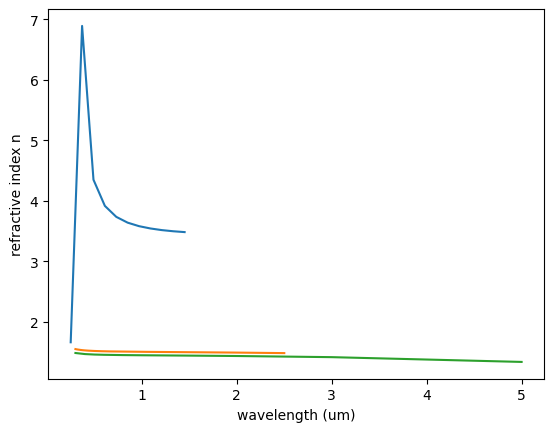

In [10]:
fig, ax = plt.subplots()
ax.plot(wl_si, n_si)
ax.plot(wl_bk7, n_bk7)
ax.plot(wl_silica, n_silica)
ax.set_xlabel('wavelength (um)')
ax.set_ylabel('refractive index n')

Matplotlib gave each line its own color, but nothing on the figure records which color
is which material.

The `label` keyword names a line as we draw it, and `ax.legend()` collects the names
into a key.

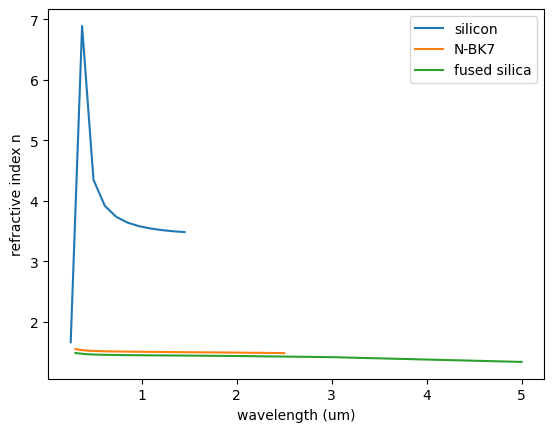

In [11]:
fig, ax = plt.subplots()
ax.plot(wl_si, n_si, label='silicon')
ax.plot(wl_bk7, n_bk7, label='N-BK7')
ax.plot(wl_silica, n_silica, label='fused silica')
ax.set_xlabel('wavelength (um)')
ax.set_ylabel('refractive index n')
ax.legend()

Now we can use the figure to answer a question. The two glasses stay near 1.5, drifting
down slowly toward the infrared, and silicon is somewhere else entirely.

It's also measured over a narrower range, which is why each material's data spans its own
wavelengths rather than a shared axis.

> Note: without a legend, three curves on one figure carry no names.

## Hard to see on this axis

On that figure the two glasses looked identical. They are not, and the reason we can't
see it is silicon: its index runs to 6.9, so everything below 2 is squashed into the
bottom fifth of the axis.

Let's plot the glasses on their own.

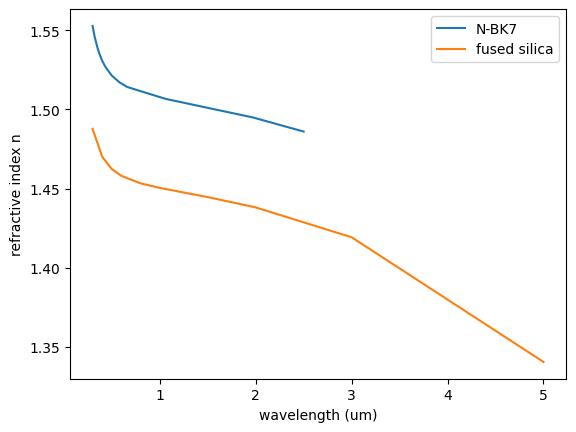

In [12]:
fig, ax = plt.subplots()
ax.plot(wl_bk7, n_bk7, label='N-BK7')
ax.plot(wl_silica, n_silica, label='fused silica')
ax.set_xlabel('wavelength (um)')
ax.set_ylabel('refractive index n')
ax.legend()

Same data, same code, one series removed, and now the difference is obvious: BK7 sits
about 0.06 above fused silica across the visible range, and both fall as the wavelength
grows.

That gap is the whole reason to choose between them for a lens. We couldn't see it in
the first figure.

> Note: an axis has to span everything on it, so putting very different materials on one
> figure costs resolution on all of them.

### [Check your understanding]

Gold is in the dataset too, as `wl_au` and `n_au`.

1. Make a `fig, ax` and plot gold's refractive index against its wavelengths, with both
   axes labeled.
2. Add fused silica to the same figure, label both lines, and draw the legend.
3. Gold's index runs from about 0.14 to 1.5, and silica's from 1.34 to 1.49. Does silica's
   line still read clearly on the shared axis?
4. Gold's index falls below 1 over part of this range, while its `k` there runs from 2.9
   to 13.8. In a comment, say which of those two numbers tells you what the light
   actually does.

## When the index drops below one

Let's look together at what you just drew.

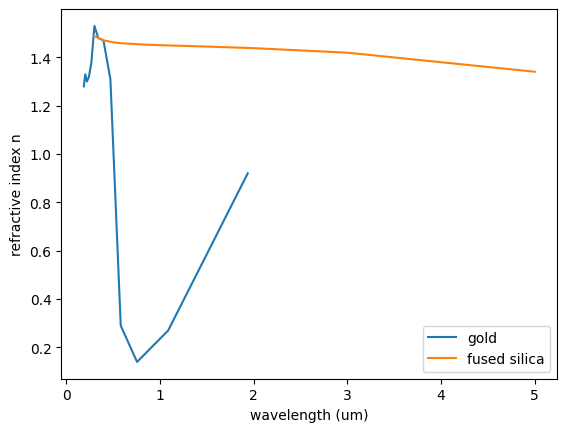

In [13]:
fig, ax = plt.subplots()
ax.plot(wl_au, n_au, label='gold')
ax.plot(wl_silica, n_silica, label='fused silica')
ax.set_xlabel('wavelength (um)')
ax.set_ylabel('refractive index n')
ax.legend()

Gold's index drops below 1 in the visible range! An `n` below 1 is a real measurement and
a signature of a metal; the crest speed it describes carries no energy, so nothing here
outruns light.

What it does not tell us is what happens to the light. Gold's `k` where its `n` dips below
1 runs from 2.9 to 13.8, and that is the column that answers the question.

# A scatter plot

A **line plot** connects the points in sequence: this measurement, then the next, along an
axis that orders them. Wavelength does that.

`n` against `k` is not a sequence. Each point is one material at one wavelength, and
joining them in file order would draw a shape that means nothing.

Text(0, 0.5, 'extinction coefficient k')

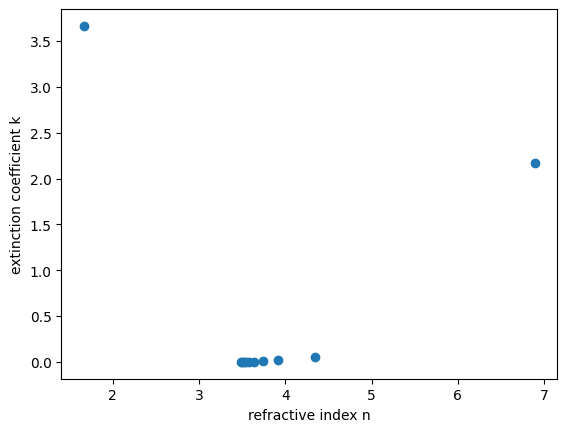

In [14]:
fig, ax = plt.subplots()
ax.scatter(n_si, k_si)
ax.set_xlabel('refractive index n')
ax.set_ylabel('extinction coefficient k')

`ax.scatter` draws the points and no line. It's the right choice whenever the x axis
doesn't put the data in an order, and the wrong choice when it does: a scatter of `n`
against wavelength would draw the same points with the curve between them gone.

Silicon's points sit in two groups: a few with large `k` in the ultraviolet, and the rest
below `k = 0.05`.

That second group is not one thing. A `k` of 0.05 is a wafer that swallows sunlight, and a
`k` of $10^{-13}$ is a wafer we can see through, and on this axis they land on the same
spot.

That is a limit of a linear axis, not a fact about silicon.

# Answering the question

The mirror and the detector both want a big `k`, so `k` alone cannot separate them. Let's
put silicon and gold side by side.

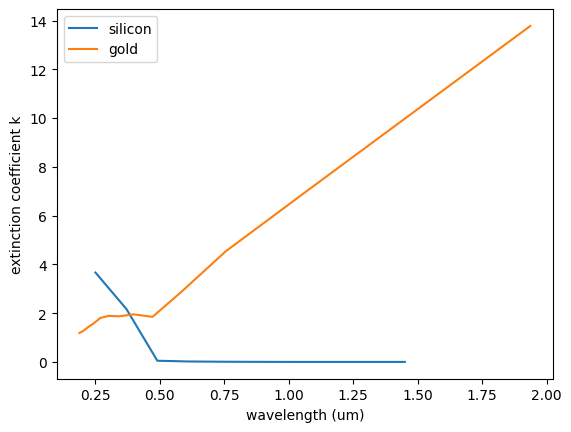

In [15]:
fig, ax = plt.subplots()
ax.plot(wl_si, k_si, label='silicon')
ax.plot(wl_au, k_au, label='gold')
ax.set_xlabel('wavelength (um)')
ax.set_ylabel('extinction coefficient k')
ax.legend()

Silicon's `k` is actually larger than gold's in the ultraviolet. Then it falls off a
cliff: 8.7e-4 at 0.97 um, 1.3e-7 at 1.21 um, 1.4e-13 at 1.45 um.

The cliff sits at 1.1 um. Silicon absorbs light shorter than that and passes light longer
than it, and the edge between the two is sharp enough to see in three numbers.

Gold's `k` has no cliff anywhere in the range.

That settles all three jobs.

The **mirror** is gold. We saw that in the opening table: red light gets 13 nm into it and
almost all of it comes straight back.

The **detector** is silicon, and only below 1.1 um. A detector has to absorb the light to
register it, and past the cliff silicon stops absorbing, so it stops detecting.

That edge is a design limit rather than a flaw.

The **lens** is one of the glasses, because a lens is the one part that has to let light
through, and only the glasses have a `k` near zero with an `n` worth bending light with.
Which glass is the question we answered earlier from the 0.06 gap.

> Note: on this data fused silica's `k` is 0 at every wavelength out to 5 um. Real silica
> has absorption bands past about 4 um that this file does not record. A column of exact
> zeros is usually a gap in the data rather than a measurement.

# Summary

* `fig, ax = plt.subplots()` makes a figure we can still reach in a later cell.
* `ax.plot(x, y)` draws a line through points in order. Use it when x orders the data.
* `ax.scatter(x, y)` draws points alone. Use it when x doesn't.
* `ax.set_xlabel` and `ax.set_ylabel` go on every figure.
* `label=` on each call plus `ax.legend()` names several series on one figure.

The answer to our question: gold is the mirror, a glass is the lens, and silicon is the
detector as long as we stay below the 1.1 um cliff in its `k`. Three plots of the same two
columns, read three different ways.

# Warm-up for Quiz 3

The quiz is on L07 and L08, so let's put those back in front of us before we start.

1. One study from L07 is stored as a dictionary:

   ```
   study = {'name': 'Cu2Se', 'best_zt': 1.13, 'temperature_C': 727}
   ```

   How do we read the best zT back out of it, and what happens if we ask for a key that
   isn't there?

2. A CSV has just been read into `data`. Which call shows us the first few rows, and
   which one shows what kind of value each column holds?

## Further reading

* VanderPlas, *Python Data Science Handbook*, "Visualization with Matplotlib"
* The data: [refractiveindex.info](https://refractiveindex.info), CC0 1.0

# Appendix A: histograms on the axes

`plt.hist` was a recipe in our hands in L06. On an `ax` it is the same three steps.

Text(0, 0.5, 'number of measurements')

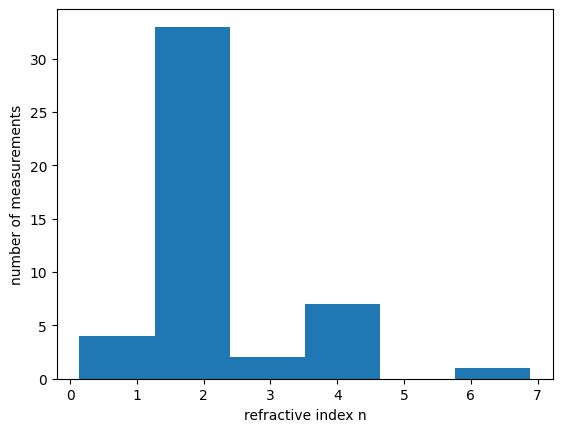

In [16]:
import numpy as np

fig, ax = plt.subplots()
ax.hist(n_all, bins=int(np.sqrt(len(n_all))))
ax.set_xlabel('refractive index n')
ax.set_ylabel('number of measurements')

Every refractive index in the file, from all four materials. Most sit between 1.3 and
1.6, which is where ordinary transparent materials live, and the long right tail is
silicon.

> Note: the square root of the number of values is a good first guess at `bins`.

A **histogram** takes one array and counts. A line and a scatter take two and pair them.

Which one to reach for depends on the question we're asking: how are these values
distributed, or how do these two quantities go together?

# Appendix B: why is it called subplots?

`plt.subplots()` is named for what it does when we ask for more than one box. The first
two arguments are the number of rows and the number of columns, and `axes` comes back as
an array with one entry per box.

(2,)


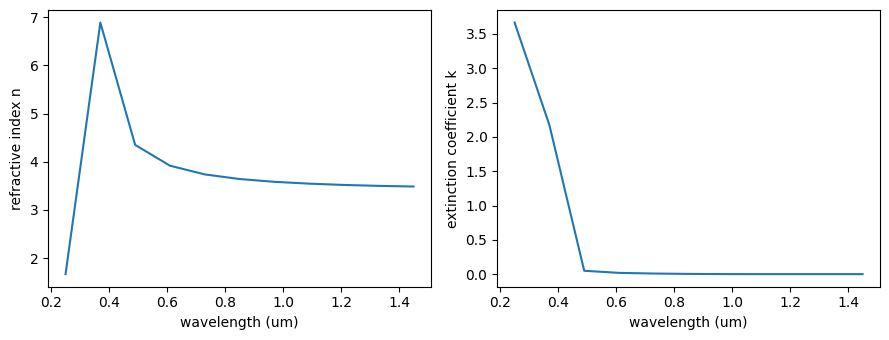

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
print(axes.shape)

axes[0].plot(wl_si, n_si)
axes[0].set_xlabel('wavelength (um)')
axes[0].set_ylabel('refractive index n')

axes[1].plot(wl_si, k_si)
axes[1].set_xlabel('wavelength (um)')
axes[1].set_ylabel('extinction coefficient k')

fig.tight_layout()

Silicon's `n` and `k` side by side, each on its own axis, so neither one squashes the
other. `fig.tight_layout()` spaces the boxes so the labels don't collide.

With no arguments, `plt.subplots()` gives one box and returns that single `ax`
directly rather than an array, which is why every figure earlier in this lecture could
write `fig, ax`.